# **Credit Flow Data Analysis & Visualization**
## Final Data Visualization Project
### Hernan Vinicio Lopez Morocho (30357360)
### Professor: Dina Deifallah

This project analyzes credit flow data to understand relationships between interested parties, credits, invoices, and payments.

## 1. Setup & Load Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

## 2. Load & Explore the Dataset

In [3]:
# Load the dataset
df = pd.read_csv('raw_credit_flow.csv')

print(f'Dataset Shape: {df.shape}')
df.info()

Dataset Shape: (28103, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28103 entries, 0 to 28102
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 28103 non-null  int64  
 1   date                       28103 non-null  object 
 2   id                         28103 non-null  int64  
 3   age                        27107 non-null  float64
 4   processed_prospect         28103 non-null  object 
 5   approval_level_analyst     417 non-null    object 
 6   approval_level_automatic   390 non-null    object 
 7   approval_level_supervisor  233 non-null    object 
 8   billing                    746 non-null    object 
 9   event_income               1578 non-null   object 
 10  risk_level                 7908 non-null   float64
 11  formality                  7881 non-null   object 
 12  supervisor_sales           28103 non-null  object 
 13  province           

In [4]:

print(f'Missing Values:')
print(df.isnull().sum())


Missing Values:
Unnamed: 0                       0
date                             0
id                               0
age                            996
processed_prospect               0
approval_level_analyst       27686
approval_level_automatic     27713
approval_level_supervisor    27870
billing                      27357
event_income                 26525
risk_level                   20195
formality                    20222
supervisor_sales                 0
province                       447
income                         783
financial_expenses           10259
dtype: int64


In [5]:
print(f' Statistics:')
print(df.describe())

 Statistics:
         Unnamed: 0            id           age   risk_level        income  \
count  28103.000000  2.810300e+04  27107.000000  7908.000000  27320.000000   
mean   29970.106181  5.476673e+11     35.154536   666.622026    480.471884   
std    16629.770530  2.601434e+11     11.693770   234.056983    319.451877   
min        9.000000  1.000982e+11      0.000000    31.800000      2.190000   
25%    16390.000000  3.211490e+11     26.000000   493.130000    302.710000   
50%    29921.000000  5.467737e+11     33.000000   733.980000    405.980000   
75%    43594.500000  7.717884e+11     42.000000   848.400000    535.052500   
max    60795.000000  9.999983e+11     96.000000   977.060000   4330.000000   

       financial_expenses  
count        17844.000000  
mean           445.563779  
std           1174.428035  
min              0.000000  
25%             39.817500  
50%            149.670000  
75%            452.675000  
max          55463.570000  


## 3. Data Cleaning

In [6]:
df_clean = df.copy()

# Convert date column to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean[df_clean['date']<'2025-12-01']
df_clean = df.drop(columns=['Unnamed: 0'])


# Remove duplicate rows
duplicates_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_after = len(df_clean)
print(f'Duplicates removed: {duplicates_before - duplicates_after}')

Duplicates removed: 0


In [7]:
## Age
df_clean = df_clean[df_clean['age'] > 18]
df_clean.groupby('age')['id'].count()

age
19.0     414
20.0     605
21.0     897
22.0     976
23.0    1040
        ... 
84.0       3
85.0       2
86.0       2
87.0       7
96.0       1
Name: id, Length: 69, dtype: int64

In [8]:
# Income
df_clean['income'] = df_clean['income'].fillna(400)
df_clean.loc[df_clean['income'] < 400, 'income'] = 400
df_clean.groupby('income')['id'].count()

income
400.00     13225
400.02         4
400.05         1
400.06         1
400.08         3
           ...  
3672.27        1
3710.00        1
3823.47        1
4294.50        1
4330.00        1
Name: id, Length: 8216, dtype: int64

In [9]:
df_clean['income'].isnull().count()



26819

In [10]:
# financial_expenses
df_clean['financial_expenses'] = df_clean['financial_expenses'].fillna(50)
df_clean.loc[df_clean['financial_expenses'] < 50, 'financial_expenses'] = 50


In [11]:

# Handle missing values
print(df_clean.isnull().sum())

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'date':
        df_clean[col] = df_clean[col].fillna('NoData')

print(f'\nMissing values after cleaning:')
print(df_clean.isnull().sum())

df_clean.shape

date                             0
id                               0
age                              0
processed_prospect               0
approval_level_analyst       26409
approval_level_automatic     26432
approval_level_supervisor    26588
billing                      26083
event_income                 25271
risk_level                   19017
formality                    19046
supervisor_sales                 0
province                       435
income                           0
financial_expenses               0
dtype: int64

Missing values after cleaning:
date                         0
id                           0
age                          0
processed_prospect           0
approval_level_analyst       0
approval_level_automatic     0
approval_level_supervisor    0
billing                      0
event_income                 0
risk_level                   0
formality                    0
supervisor_sales             0
province                     0
income                     

(26819, 15)

In [12]:
df_clean.head()

,date,id,age,processed_prospect,approval_level_analyst,approval_level_automatic,approval_level_supervisor,billing,event_income,risk_level,formality,supervisor_sales,province,income,financial_expenses
0,2025-06-29 19:51:39.837,318266204038,19.0,no,NoData,NoData,NoData,NoData,NoData,0.0,NoData,Sup_1,Manabí,400.00,50.00
1,2025-10-06 19:16:11.670,124300961898,33.0,no,NoData,NoData,NoData,NoData,NoData,0.0,NoData,noclient,Pichincha,400.00,104.13
2,2025-02-07 19:49:27.063,117458648243,38.0,no,NoData,NoData,NoData,NoData,NoData,0.0,NoData,noclient,Pichincha,1909.63,1229.73
3,2025-10-15 23:28:43.057,791410273242,31.0,yes,NoData,NoData,NoData,NoData,NoData,0.0,NoData,noclient,Pichincha,479.38,50.00
4,2025-01-23 15:13:35.550,852798701019,43.0,no,NoData,NoData,NoData,NoData,NoData,0.0,NoData,noclient,Pichincha,492.46,50.00


## 4. Feature Engineering

In [13]:
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')
if df_clean['date'].isna().any():
    print(f"Warning: {df_clean['date'].isna().sum()} invalid date(s) found and set to NaT")

df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['month_name'] = df_clean['date'].dt.strftime('%B')
df_clean['day'] = df_clean['date'].dt.day
df_clean['quarter'] = df_clean['date'].dt.quarter

df_clean['income_category'] = pd.cut(df_clean['income'], 
                                       bins=[0, 500, 1000, 2000, 5000, float('inf')],
                                       labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])



In [14]:
df_clean.to_csv('credit_flow_cleaned.csv')

## 5. Analytical Questions & Visualizations



Dataframes necesaries to create the visualization in the correct stage of the process

In [16]:
p_preaproved = df_clean[df_clean['processed_prospect'] == 'yes']
p_credit_form = p_preaproved[p_preaproved['event_income']=='begin_event']
p_credit_invoice = p_credit_form[p_credit_form['billing']=='invoice']


### Question 1: What is the flow of the credits in the company?

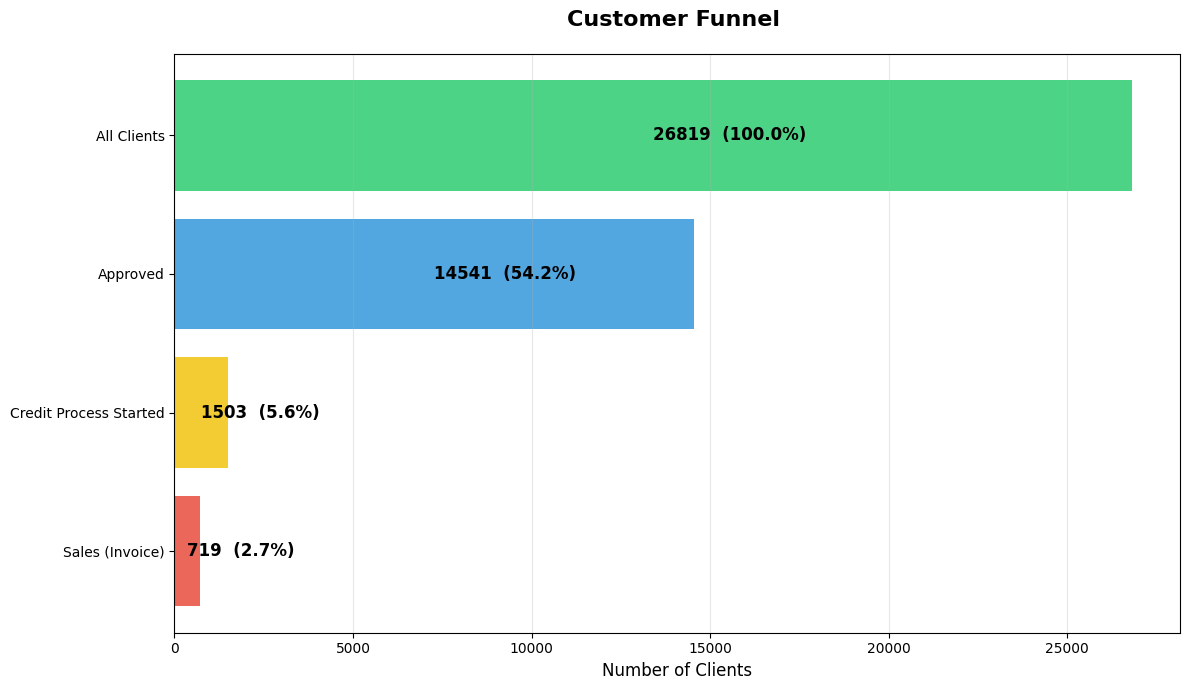

In [17]:
counts = [
    len(df_clean),
    len(p_preaproved),
    len(p_credit_form),
    len(p_credit_invoice)
]

stages = [
    "All Clients",
    "Approved",
    "Credit Process Started",
    "Sales (Invoice)"
]

total = counts[0]
percentages = [(c / total) * 100 for c in counts]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(stages, counts, color=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c'], alpha=0.85)

for i, bar in enumerate(bars):
    width = bar.get_width()
    label = f"{counts[i]}  ({percentages[i]:.1f}%)"
    
    ax.text(
        width * 0.5,          
        bar.get_y() + bar.get_height() / 2,
        label,
        ha='left',
        va='center',
        fontsize=12,
        color='black',
        fontweight='bold'
    )

ax.set_xlabel("Number of Clients", fontsize=12)
ax.set_title("Customer Funnel ", fontsize=16, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

- In this period of time, we have a 2.7% of conversion rate of those interested in credit, which is a good outcome, but we can improve almost the 5.6%. We can analyze the reason why the credits that begin the process don't convert in sale.
- From the aproved we need to see if we can improve the score of the clients and get a bit of risk and star more credits. Almost get the 10% of the credit process started. Firt we need to see the reports of the people with default or people who don't pay the credit.
- Increase the marketing campaign for the credit to reach more people in order to increase the conversion.

### Question 2: What is the distribution of pre-approved, aproved and credit started and sales with formality.

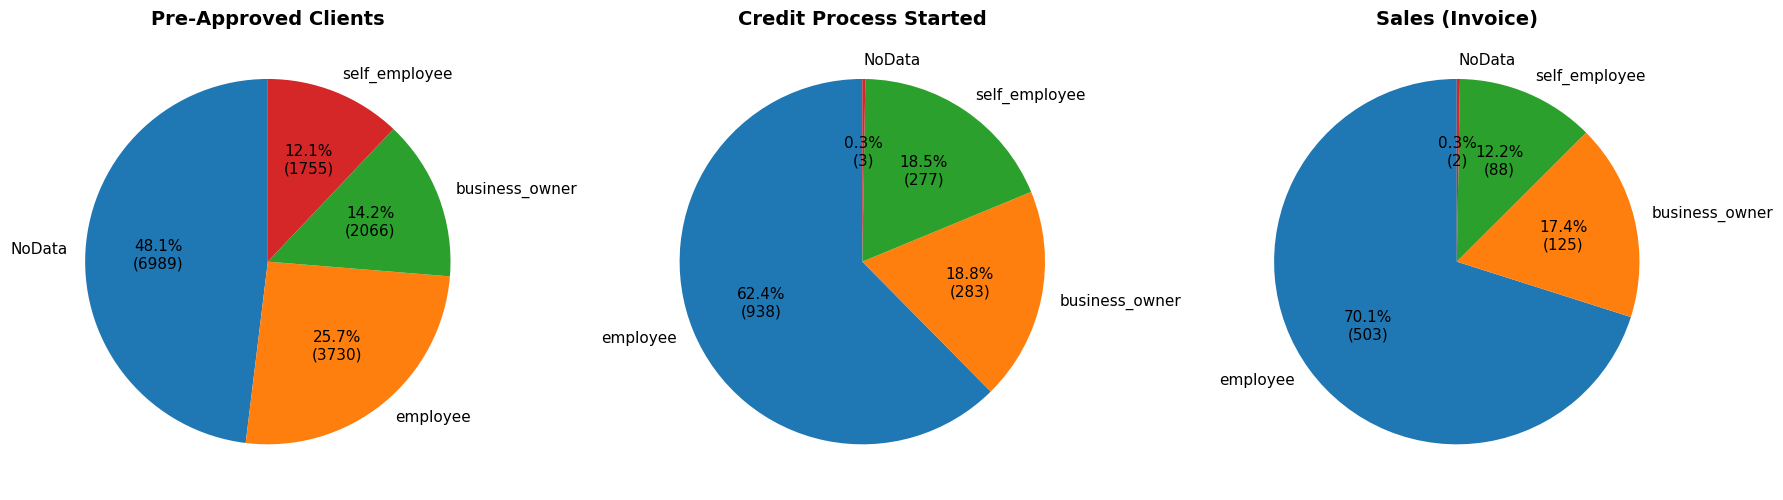

In [18]:

dfs = [
    p_preaproved,
    p_credit_form,
    p_credit_invoice
]

titles = [
    "Pre‑Approved Clients",
    "Credit Process Started",
    "Sales (Invoice)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, df_stage, title in zip(axes, dfs, titles):
    
    counts = df_stage['formality'].value_counts()
    
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct=lambda p: f'{p:.1f}%\n({int(p * sum(counts) / 100)})',
        startangle=90,
        textprops={'fontsize': 11}
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

- We can notice that the people with formal employee has more credits, it is a good signal but we can improve until 80%.
- Also we know if the people doesnt have information about their employee is rejected, only we have some people with NO DATA that pass through the filter due a exeptions.

### Question 3: How does income and expenses distribution look across all customers with credit form?

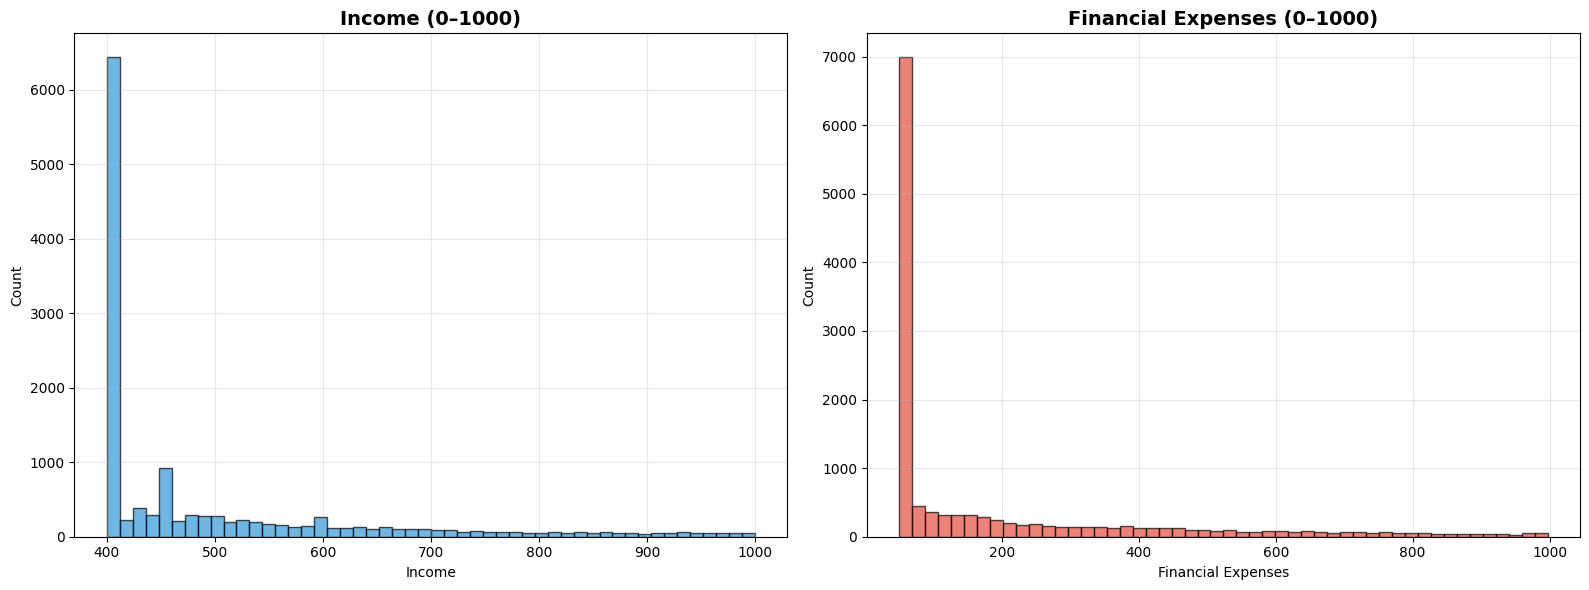

In [19]:

income_filtered = p_preaproved['income'].loc[(p_preaproved['income'] >= 0) & 
                                             (p_preaproved['income'] <= 1000)]

expenses_filtered = p_preaproved['financial_expenses'].loc[(p_preaproved['financial_expenses'] >= 0) & 
                                                           (p_preaproved['financial_expenses'] <= 1000)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Income
axes[0].hist(income_filtered, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Income (0–1000)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Financial Expenses
axes[1].hist(expenses_filtered, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Financial Expenses (0–1000)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Financial Expenses')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The majority of our clients have low income and also low expenses. Our segment of market is risk but is the field we accept the sales of this amount od credits.

### Question 4: What are the top 10 provinces by credit pre_aprove by province and conversion?

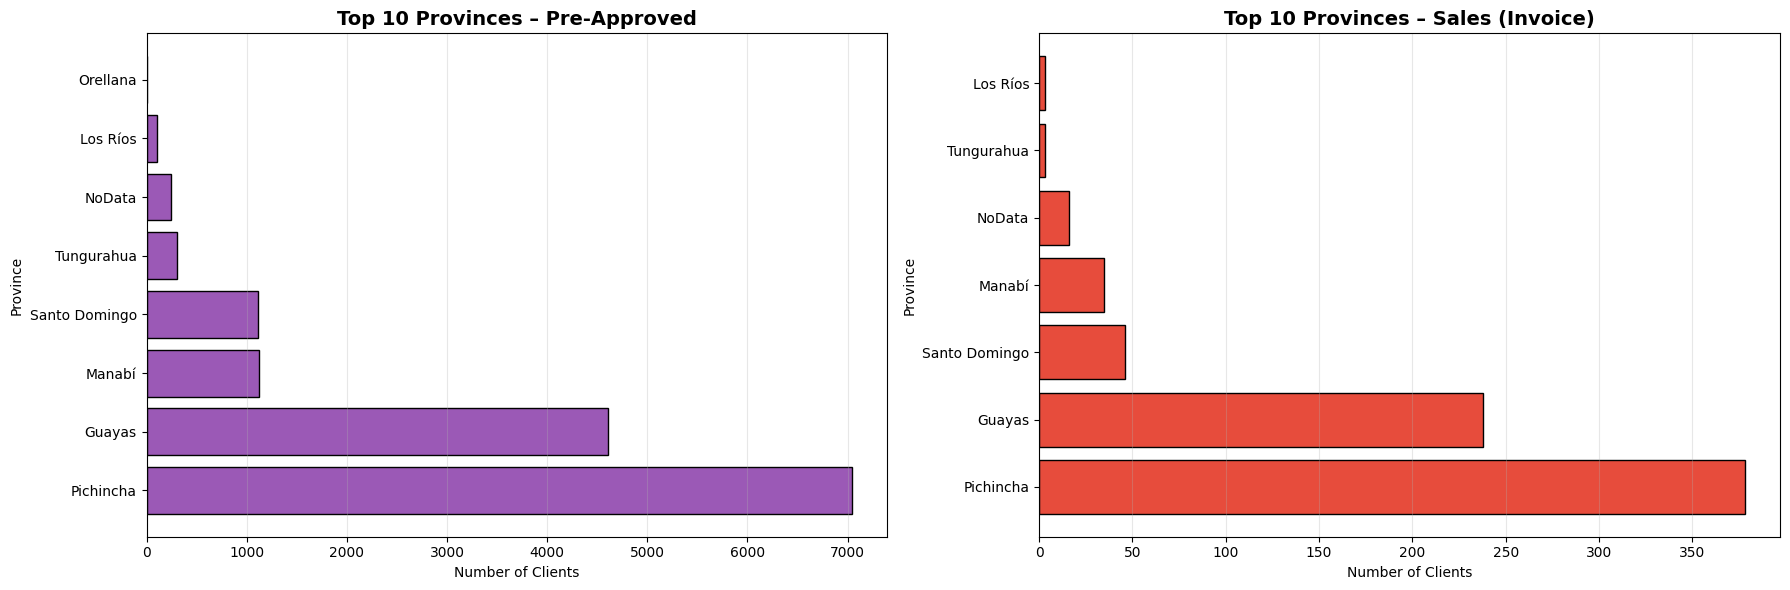

In [20]:
prov_pre = p_preaproved['province'].value_counts().head(10)
prov_sales = p_credit_invoice['province'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Pre‑Approved 
axes[0].barh(prov_pre.index, prov_pre.values, color='#9b59b6', edgecolor='black')
axes[0].set_title('Top 10 Provinces – Pre‑Approved', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clients')
axes[0].set_ylabel('Province')
axes[0].grid(True, axis='x', alpha=0.3)

# Sales (Invoice)
axes[1].barh(prov_sales.index, prov_sales.values, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 10 Provinces – Sales (Invoice)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clients')
axes[1].set_ylabel('Province')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

- We see the same patern but with a slightly diference, for example Santo Domingo has a better conversion, NoData info, are the clients from web, no a specifict store.
- Finally que can improve the sales in Guayas one of the largest cities in Ecuador, we can suggest a strong marketing campain and also the posibility to create a new phisical store.

### Question 5: What is the age distribution of applicants by each stage?

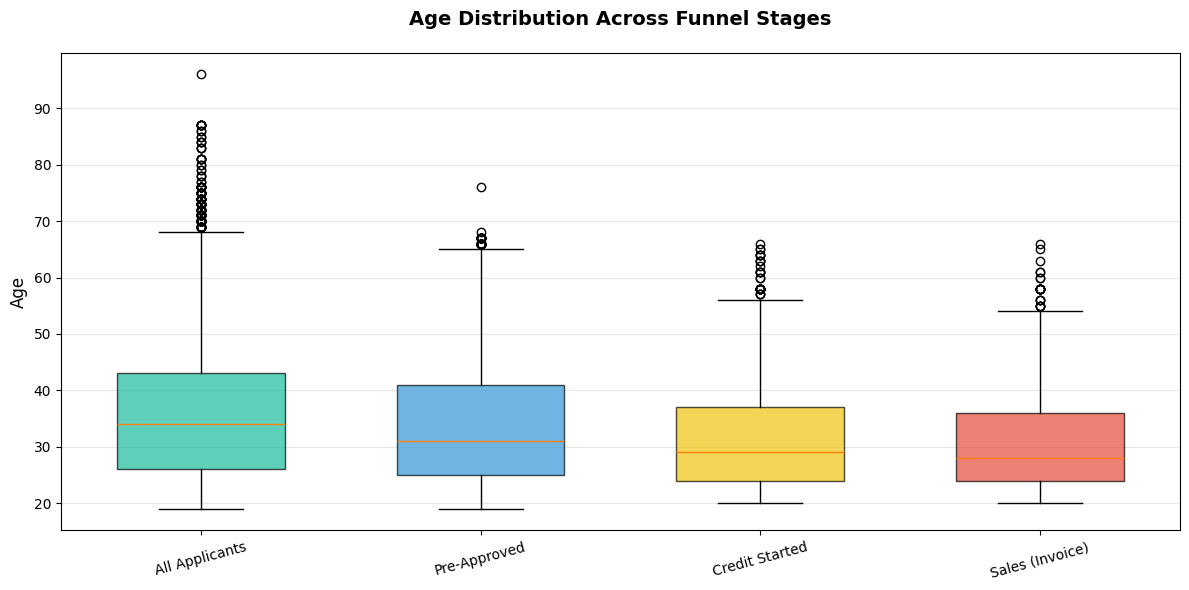

In [21]:

age_data = [
    df_clean['age'],
    p_preaproved['age'],
    p_credit_form['age'],
    p_credit_invoice['age']
]

labels = [
    "All Applicants",
    "Pre‑Approved",
    "Credit Started",
    "Sales (Invoice)"
]

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(age_data, patch_artist=True, widths=0.6)

colors = ['#1abc9c', '#3498db', '#f1c40f', '#e74c3c']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Age', fontsize=12)
ax.set_title('Age Distribution Across Funnel Stages', fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(labels, rotation=15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

- The top of the funnel attracts people from a very wide age range, including many older applicants.

- As the funnel progresses, older ages drop out, and no one above 68 reaches the sales stage.

- The median age consistently decreases from applicants, pre‑approved, credit started, and conversion.

- Your product converts best among younger clients, while older applicants show interest but rarely complete the process.


### Question 6: How do financial expenses relate to income?

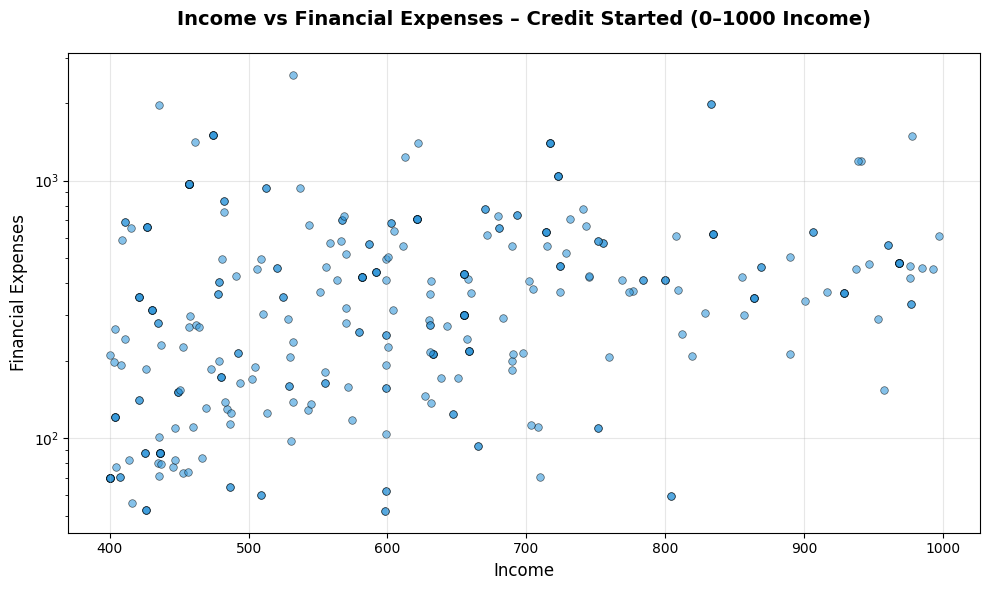

In [22]:
df_form_scatter = p_credit_form[
    (p_credit_form['financial_expenses'] > 51) &
    (p_credit_form['income'] > 400) &
    (p_credit_form['income'] <= 1000)
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df_form_scatter['income'],
    df_form_scatter['financial_expenses'],
    color='#3498db',
    alpha=0.6,
    s=30,
    edgecolor='black',
    linewidth=0.5
)

ax.set_xlabel('Income', fontsize=12)
ax.set_ylabel('Financial Expenses', fontsize=12)
ax.set_title('Income vs Financial Expenses – Credit Started (0–1000 Income)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

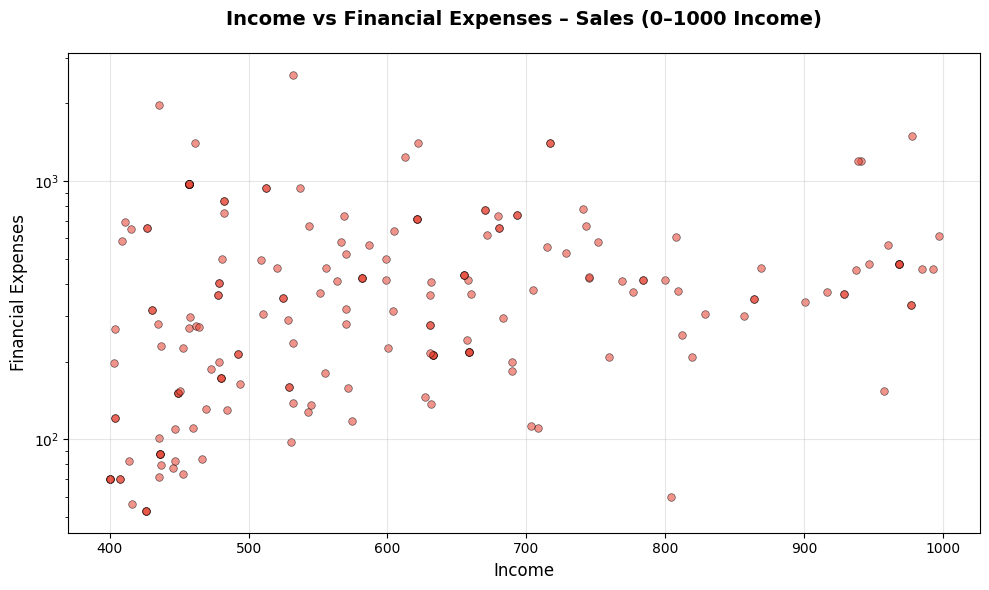

In [23]:
# Scatter for p_credit_invoice
df_invoice_scatter = p_credit_invoice[
    (p_credit_invoice['financial_expenses'] > 51) &
    (p_credit_invoice['income'] > 400) &
    (p_credit_invoice['income'] <= 1000)
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df_invoice_scatter['income'],
    df_invoice_scatter['financial_expenses'],
    color='#e74c3c',
    alpha=0.6,
    s=30,
    edgecolor='black',
    linewidth=0.5
)

ax.set_xlabel('Income', fontsize=12)
ax.set_ylabel('Financial Expenses', fontsize=12)
ax.set_title('Income vs Financial Expenses – Sales (0–1000 Income)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Financial expenses still vary widely, but the log scale reveals a more structured pattern instead of a chaotic vertical cloud.
- Lower‑income clients show greater variability in expenses, while higher‑income clients cluster more tightly, suggesting more stable financial behavior.
- Finally we can see the pattern that we can suggest and it is with more income we have more expenses.



### Question 7: How many credits were processed each month?

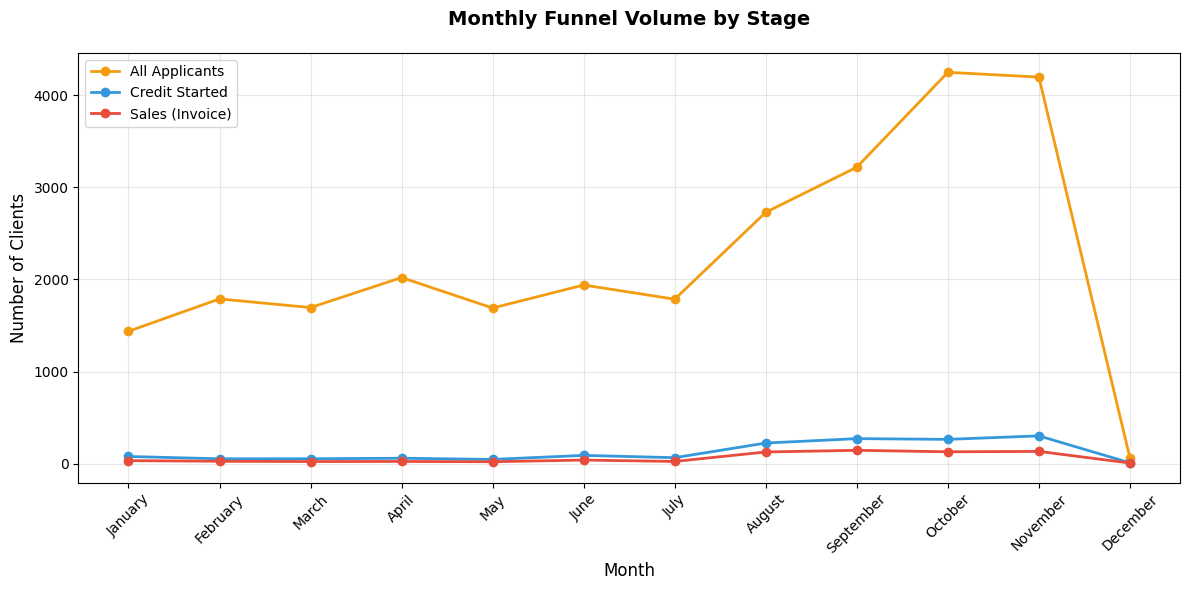

In [24]:

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_all = df_clean.groupby('month_name').size().reindex(month_order)
monthly_form = p_credit_form.groupby('month_name').size().reindex(month_order)
monthly_invoice = p_credit_invoice.groupby('month_name').size().reindex(month_order)


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(month_order, monthly_all.values, marker='o', linewidth=2,
        label='All Applicants', color='#f39c12')
ax.plot(month_order, monthly_form.values, marker='o', linewidth=2,
        label='Credit Started', color='#3498db')
ax.plot(month_order, monthly_invoice.values, marker='o', linewidth=2,
        label='Sales (Invoice)', color='#e74c3c')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Clients', fontsize=12)
ax.set_title('Monthly Funnel Volume by Stage', fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

- All applicants peak in October–November, showing strong seasonal demand late in the year and also the increase of the marketing campaing 
- Credit Started grows slowly and peaks in November, but stays far below total applicants.
- Sales (Invoice) peak around September–October.
- There’s a big drop‑off between stages, meaning only a small fraction of applicants reach the final sale.
This is normal because 


### Question 8: Level of approval by supervisor of sales from convertions ( responsibility)

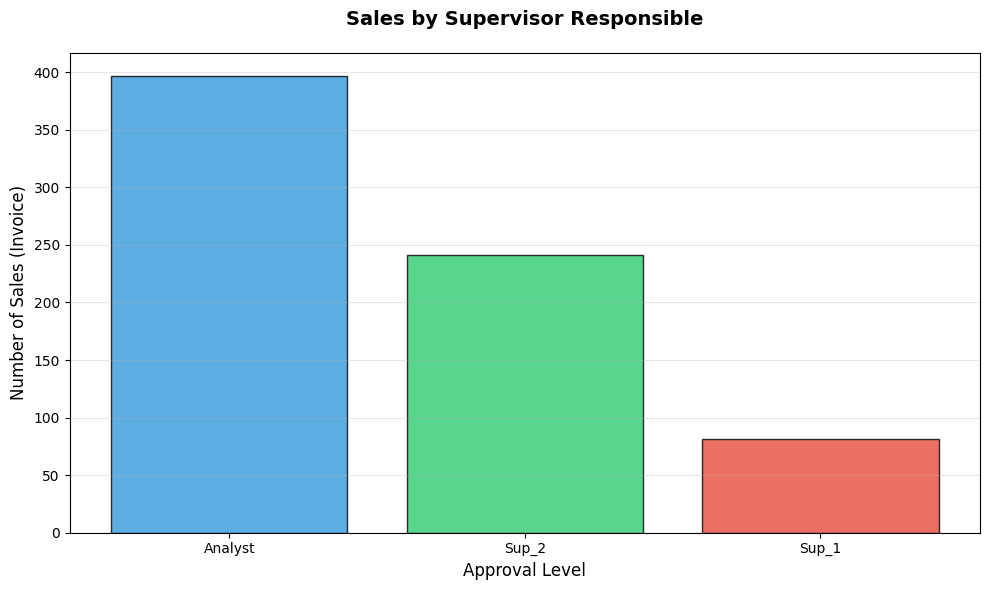

In [25]:
approval_counts = (
    p_credit_invoice['supervisor_sales']
    .replace({'noclient': 'Analyst'})
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    approval_counts.index,
    approval_counts.values,
    color=['#3498db', '#2ecc71', '#e74c3c'],
    edgecolor='black',
    alpha=0.8
)

ax.set_xlabel('Approval Level', fontsize=12)
ax.set_ylabel('Number of Sales (Invoice)', fontsize=12)
ax.set_title('Sales by Supervisor Responsible', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

- The Analyst category dominates the final sales stage, meaning most successful invoices come from cases handled at this level. This suggests analysts are either receiving the strongest applicants or applying criteria that lead to higher conversion.

- We need to see the number of stores in charge to all supervisors and see what is the best 

### Question 9: scoring histogram by stage?

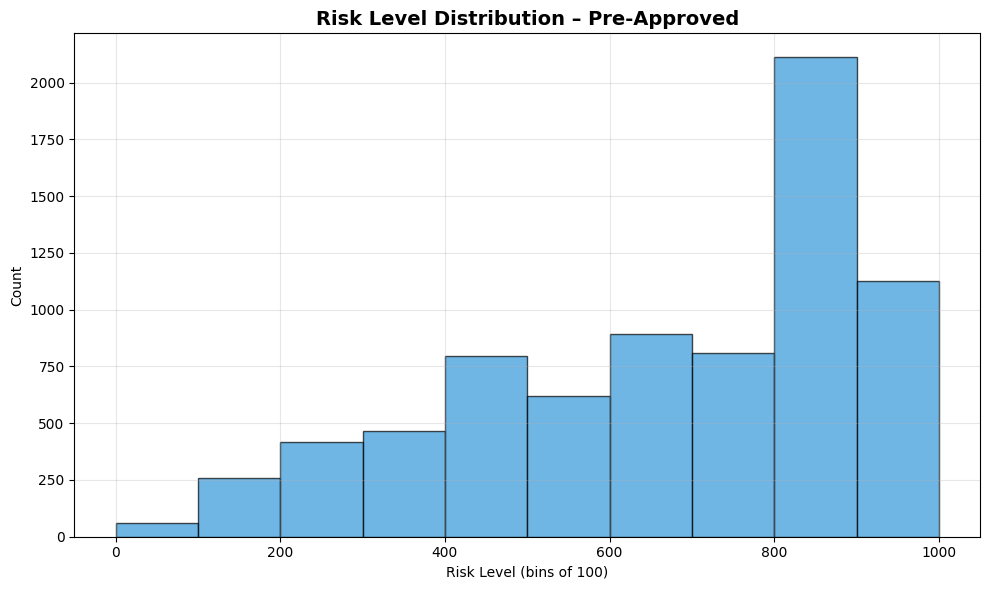

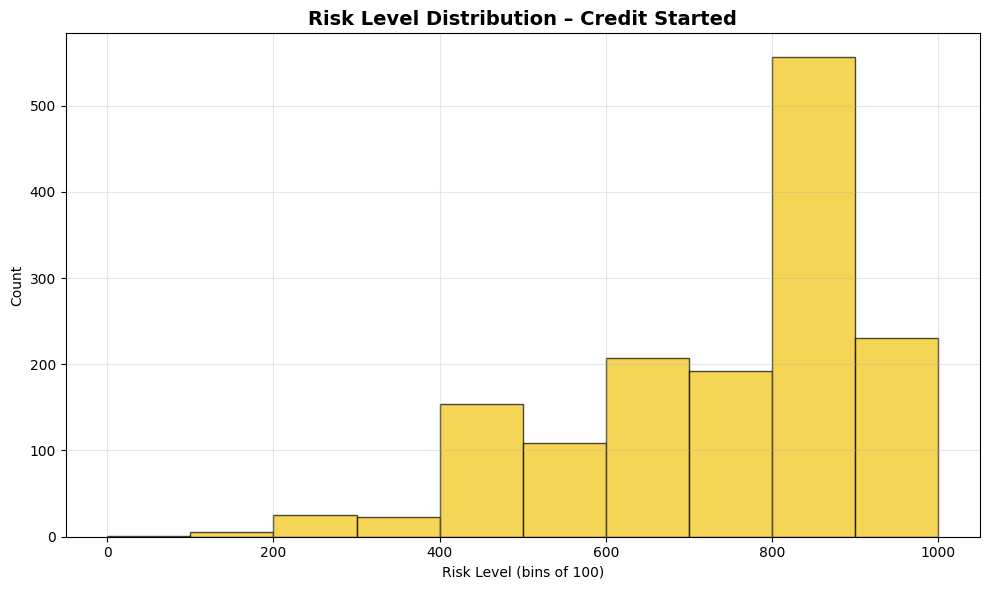

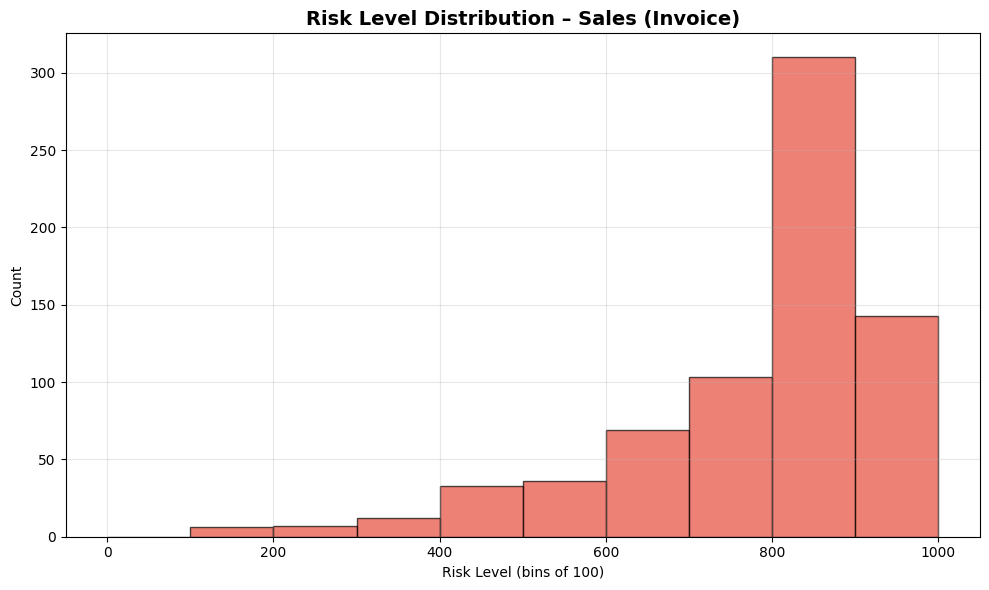

In [26]:

bins = np.arange(0, 1100, 100)

hist_pre = p_preaproved[p_preaproved['risk_level'] > 0]
hist_form = p_credit_form[p_credit_form['risk_level'] > 0]
hist_invoice = p_credit_invoice[p_credit_invoice['risk_level'] > 0]

# Pre-Approved 
plt.figure(figsize=(10, 6))
plt.hist(hist_pre['risk_level'], bins=bins, color='#3498db', edgecolor='black', alpha=0.7)
plt.title("Risk Level Distribution – Pre-Approved", fontsize=14, fontweight='bold')
plt.xlabel("Risk Level (bins of 100)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Credit Started 
plt.figure(figsize=(10, 6))
plt.hist(hist_form['risk_level'], bins=bins, color='#f1c40f', edgecolor='black', alpha=0.7)
plt.title("Risk Level Distribution – Credit Started", fontsize=14, fontweight='bold')
plt.xlabel("Risk Level (bins of 100)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sales (Invoice) 
plt.figure(figsize=(10, 6))
plt.hist(hist_invoice['risk_level'], bins=bins, color='#e74c3c', edgecolor='black', alpha=0.7)
plt.title("Risk Level Distribution – Sales (Invoice)", fontsize=14, fontweight='bold')
plt.xlabel("Risk Level (bins of 100)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- The biggest concentration is in the 800–900 bin, meaning the majority of pre‑approved people have high‑risk scores.
- The 900–1000 scorte is the next biggest, reinforcing that pre‑approval.
- Low and medium risk levels are almost nonexistent Score below 700 barely appear, showing that very few low‑risk clients reach pre‑approval.
- The next step is be aware with the default people



### Question 10: Map of the sales to visualize the regions to improve the sales?

In [27]:
import plotly.express as px
import json

sales_by_province = (
    p_credit_invoice['province']
    .str.upper()
    .str.replace('[ÁÉÍÓÚÑ]', lambda x: {'Á':'A','É':'E','Í':'I','Ó':'O','Ú':'U','Ñ':'N'}[x.group()], regex=True)
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'sales', 'province': 'province'})
)

with open('ecuador.geojson', 'r') as f:
    geo = json.load(f)

for feature in geo['features']:
    if 'nombre' in feature['properties']:
        name = feature['properties']['nombre']
        feature['properties']['nombre_clean'] = (
            name.upper()
            .replace('Á','A').replace('É','E').replace('Í','I')
            .replace('Ó','O').replace('Ú','U').replace('Ñ','N')
        )

fig = px.choropleth(
    sales_by_province,
    geojson=geo,
    locations='province',
    featureidkey='properties.nombre_clean',
    color='sales',
    color_continuous_scale='Blues',
    title='Sales by Province - Ecuador'
)

fig.update_geos(
    fitbounds="locations",
    visible=True,
    showcountries=True,
    showcoastlines=True,
    showland=True,
    landcolor="lightgray",
    subunitcolor="gray",    
    subunitwidth=0.5        
)

fig.update_traces(
    marker_line_width=0.5,  
    marker_line_color='darkgray'
)

fig.show()



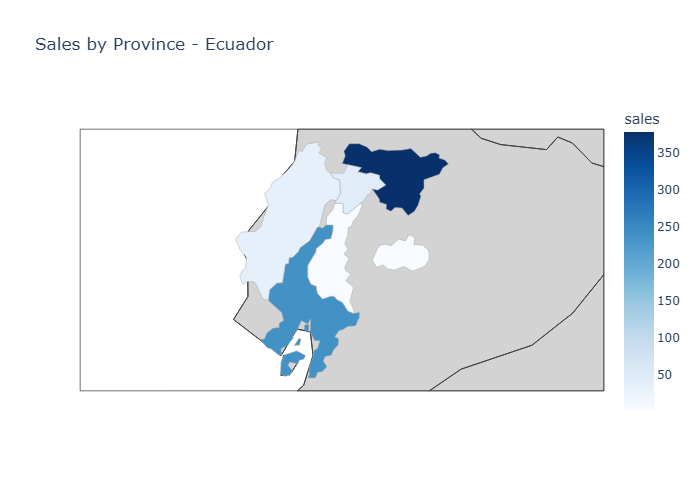

In [28]:
# necesary for HTML
display(Image(filename='sales_map.png', width=800))

- Guayas and Pichincha dominate credit sales; these two provinces clearly generate the highest conversion rates.
- Manabí, El Oro, and Santa Elena show a stronger conversion rate than many Andean provinces.
- We can shift our strategy toward the coastal region to boost these sales through marketing and by leasing new locations.
